# Explore output coordinates

Install `rainbow-tensor[interactive]` in this notebook kernel environment first. Live controls need a notebook host with Jupyter widget support.

In [7]:
import numpy as np

import rainbow_tensor as rt

a = np.arange(6).reshape(2, 3)
b = np.arange(12).reshape(3, 4)
explorer = rt.explore(rt.matmul, a, b, focus=(1, 2))
explorer

## Change the output

Edit the coordinate fields and press **Update focus**, or use Python. Negative coordinates count from the end. The latest static visual remains available.

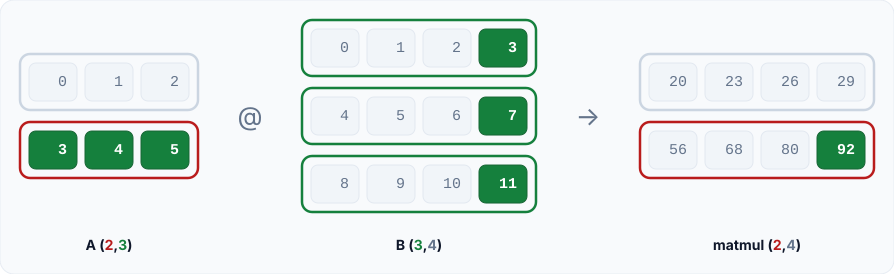

Operand shapes: (2, 3) @ (3, 4)
Left rows: 2, right columns: 4, shared inner axis: 3.
Result shape: (2, 4)
The highlighted row and column combine into the focused output element.
Numerical model: Python scalar arithmetic.
Accumulation dtype, rounding, and overflow may differ from the input array backend.
Focus: output (1, 3) uses 3 terms.
output[1, 3] = A[1, 0] * B[0, 3] + A[1, 1] * B[1, 3] + A[1, 2] * B[2, 3]


In [8]:
explorer.set_focus((-1, -1))
assert explorer.visual.trace.output_coord == (1, 3)
explorer.visual

## Preserve a valid figure when an update fails

An invalid Python update raises a clear error. It does not replace the previous visual.

In [9]:
previous = explorer.visual
try:
    explorer.set_focus((2, 0))
except IndexError as error:
    print(error)
assert explorer.visual is previous

focus axis 0: index 2 is out of range for size 2


## Keep arithmetic budgets in effect

The large reduction stays unevaluated when its term count exceeds the budget. Changing focus does not enable an expensive calculation.

In [10]:
limited = rt.explore(rt.sum, (2, 100_000), axis=1, max_terms=100)
limited.set_focus((1,))
assert limited.visual.metadata["value_evaluation"]["status"] == "skipped"
limited

## Understand the numerical model

The preview uses Python scalar arithmetic. A backend kernel can use different accumulation dtype, rounding, or overflow behavior.

NumPy float32 sum: 0.0


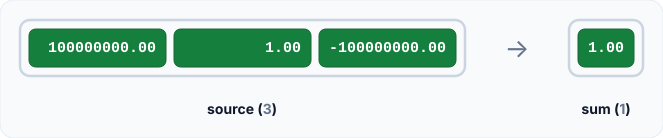

Original shape: (3,)
Reducing axis 0 with sum.
Result shape: ()
Each result element combines 3 values from axis 0.
Values that fold into the same result share one background with that result element, and the first group is highlighted.
Numerical model: Python scalar arithmetic.
Accumulation dtype, rounding, and overflow may differ from the input array backend.


In [11]:
values = np.array([1e8, 1, -1e8], dtype=np.float32)
print("NumPy float32 sum:", np.sum(values))
rt.sum(values, axis=0)

The latest figure can be saved with `explorer.visual.save("focused-output.svg")`. Close the controls when finished to release their widget communications.

In [12]:
explorer.close()
limited.close()